In [1]:
# from opticalib.ground import osutils as osu

from astropy.io import fits

import matplotlib.pyplot as plt
# from matplotlib.ticker import AutoMinorLocator
import numpy as np
import os

(1e-08, 0.1)

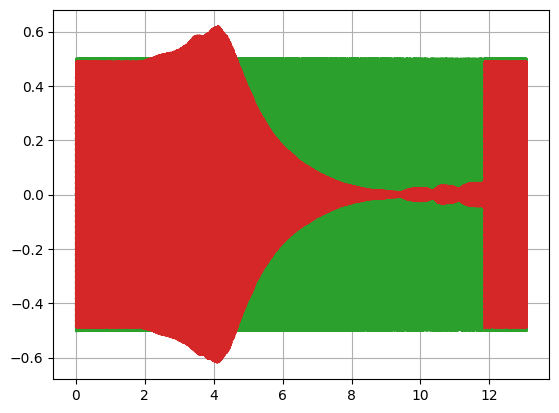

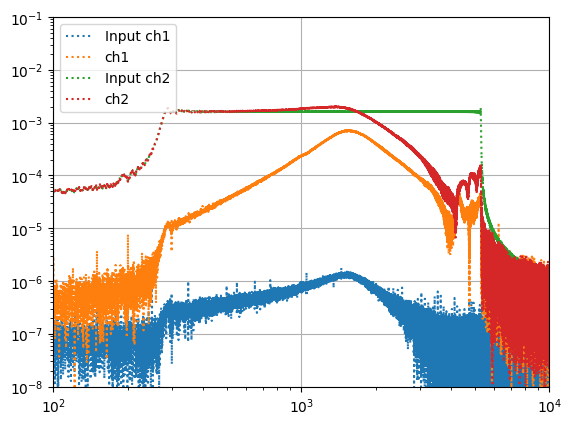

In [61]:
webdaqpath = '/mnt/jumbo/SPLATT/WebDaqData'
freq = 51200

def read_fits(filename):
    hdu = fits.open(filename)
    data = hdu[0].data
    return data

def read_wbdq_data(tn,show:bool=False):
    filename = os.path.join(webdaqpath,tn)+'.fits'
    data = read_fits(filename) #osu.load_fits(filename)
    # raw_data = osu.load_fits(filename)
    # raw_data = raw_data.flatten()
    # data = np.zeros((4, len(raw_data)//4))
    # for i in range(4):
    #     data[i] = raw_data[i::4]
    tvec = np.arange(data.shape[1])/freq
    if show:
        plt.figure()
        plt.plot(tvec,data[1],':')
        plt.plot(tvec,data[0],':')
        plt.plot(tvec,data[2],':')
        plt.plot(tvec,data[3],':')
        plt.grid()
        # plt.xlim([0,0.001])
    return data, tvec

def get_spectrum(signal, dt=1, phase = False):
    spe = np.fft.rfft(signal, norm="ortho", axis=-1)
    nn = np.sqrt(spe.shape[-1])
    spe_mod = (np.abs(spe)) / nn
    freq = np.fft.rfftfreq(signal.shape[-1], d=dt)
    if len(np.shape(spe))>1:
        spe_mod[:,0] = 0
    else:
        spe_mod[0] = 0
    if phase is True:
        spe_phi = np.angle(spe)
        return spe_mod, freq, spe_phi
    else:
        return spe_mod, freq
    
data,tvec = read_wbdq_data('20260304_143314',show=True)
tstart = 2
tend = 11.5
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]

spe1,f = get_spectrum(data[0], dt=1/freq)
spe2,f = get_spectrum(data[1], dt=1/freq)
spe3,f = get_spectrum(data[2], dt=1/freq)
spe4,f = get_spectrum(data[3], dt=1/freq)
plt.figure()
plt.plot(f,spe1,':',label='Input ch1')
plt.plot(f,spe2,':',label='ch1')
plt.plot(f,spe3,':',label='Input ch2')
plt.plot(f,spe4,':',label='ch2')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e+2,1e+4])
plt.ylim([1e-8,1e-1])

In [3]:
def get_spectra_from_tns(tns:list,fs:float,tstart=None,tend=None):
    spe_rms = None
    for tn in tns:
        data,tvec = read_wbdq_data(tn,show=False)
        if tstart is not None:
            data = data[:,tvec>tstart]
            tvec = tvec[tvec>tstart]
        if tend is not None:
            data = data[:,tvec<tend]
            tvec = tvec[tvec<tend]
        spe,f = get_spectrum(data, dt=1/fs)
        if spe_rms is None:
            spe_rms = spe**2
        else:
            spe_rms += spe**2
    spe_rms = np.sqrt(spe_rms)/len(tns)
    return spe_rms,f

Text(0.5, 1.0, 'Transfer function ratio\nChannel 2 / Channel 1')

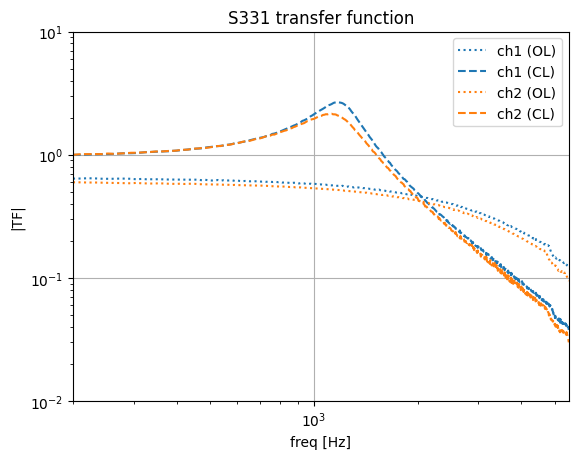

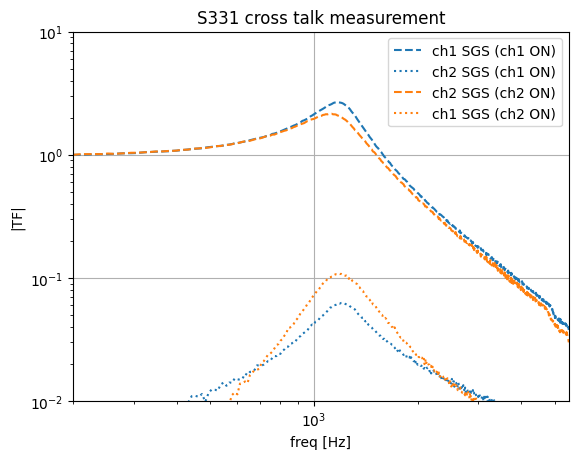

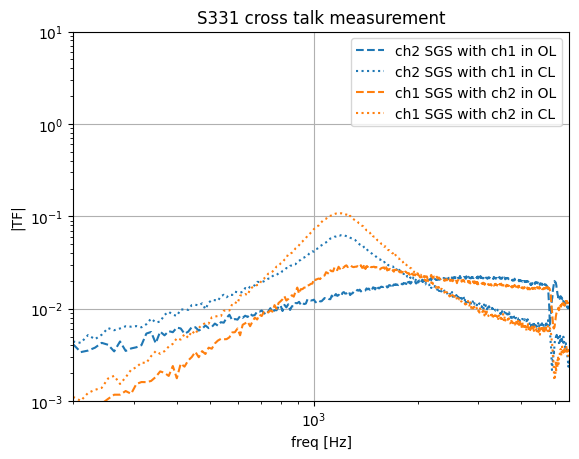

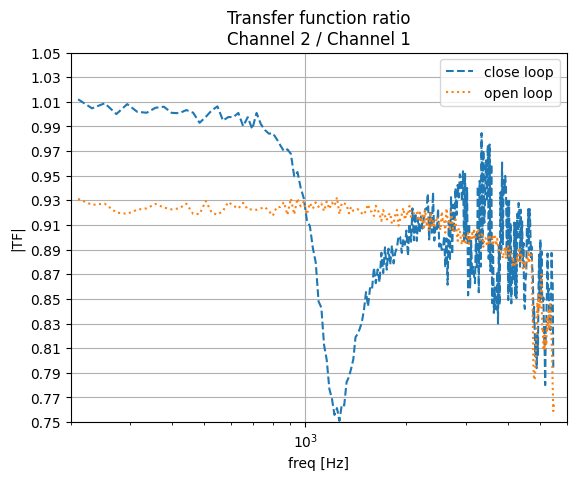

In [5]:
ch1_oltf = np.ones_like(spe1)*np.nan
ch2_oltf = np.ones_like(spe1)*np.nan
ch1_cltf = np.ones_like(spe1)*np.nan
ch2_cltf = np.ones_like(spe1)*np.nan
ch1_oltf_ct = np.ones_like(spe1)*np.nan
ch2_oltf_ct = np.ones_like(spe1)*np.nan
ch1_cltf_ct = np.ones_like(spe1)*np.nan
ch2_cltf_ct = np.ones_like(spe1)*np.nan

frange = (f>200)*(f<5500)
spe,f = get_spectra_from_tns(['20260227_143926','20260227_143948'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf[frange] = spe[1,frange]/spe[0,frange]
ch1_cltf_ct[frange] = spe[3,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_143650','20260227_143631'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf[frange] = spe[1,frange]/spe[0,frange]
ch1_oltf_ct[frange] = spe[3,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_144243','20260227_144306'],fs=freq,tstart=tstart,tend=tend)
ch2_cltf[frange] = spe[3,frange]/spe[2,frange]
ch2_cltf_ct[frange] = spe[1,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260227_144140','20260227_144200'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf[frange] = spe[3,frange]/spe[2,frange]
ch2_oltf_ct[frange] = spe[1,frange]/spe[2,frange]

dec = 100
plt.figure()
plt.plot(f[::dec],ch1_oltf[::dec],':',c='C0',label='ch1 (OL)')
plt.plot(f[::dec],ch1_cltf[::dec],'--',c='C0',label='ch1 (CL)')
plt.plot(f[::dec],ch2_oltf[::dec],':',c='C1',label='ch2 (OL)')
plt.plot(f[::dec],ch2_cltf[::dec],'--',c='C1',label='ch2 (CL)')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,5500])
plt.ylim([1e-2,10])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S331 transfer function')

plt.figure()
plt.plot(f[::dec],ch1_cltf[::dec],'--',c='C0',label='ch1 SGS (ch1 ON)')
plt.plot(f[::dec],ch1_cltf_ct[::dec],':',c='C0',label='ch2 SGS (ch1 ON)')
plt.plot(f[::dec],ch2_cltf[::dec],'--',c='C1',label='ch2 SGS (ch2 ON)')
plt.plot(f[::dec],ch2_cltf_ct[::dec],':',c='C1',label='ch1 SGS (ch2 ON)')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,5500])
plt.ylim([1e-2,10])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S331 cross talk measurement')

plt.figure()
plt.plot(f[::dec],ch1_oltf_ct[::dec],'--',c='C0',label='ch2 SGS with ch1 in OL')
plt.plot(f[::dec],ch1_cltf_ct[::dec],':',c='C0',label='ch2 SGS with ch1 in CL')
plt.plot(f[::dec],ch2_oltf_ct[::dec],'--',c='C1',label='ch1 SGS with ch2 in OL')
plt.plot(f[::dec],ch2_cltf_ct[::dec],':',c='C1',label='ch1 SGS with ch2 in CL')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,5500])
plt.ylim([1e-3,10])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S331 cross talk measurement')

dec = 200
plt.figure()
plt.plot(f[::dec],ch2_cltf[::dec]/ch1_cltf[::dec],'--',label='close loop')
plt.plot(f[::dec],ch2_oltf[::dec]/ch1_oltf[::dec],':',label='open loop')
plt.legend()
plt.grid()
plt.xscale('log')
plt.xlim([200,6000])
plt.ylim([0.75,1.02])
plt.xlabel('freq [Hz]')
plt.yticks(np.arange(16)/50+0.75)
plt.ylabel('|TF|')
plt.title('Transfer function ratio\nChannel 2 / Channel 1')

Text(0.5, 1.0, 'Transfer function ratio\nChannel 2 / Channel 1')

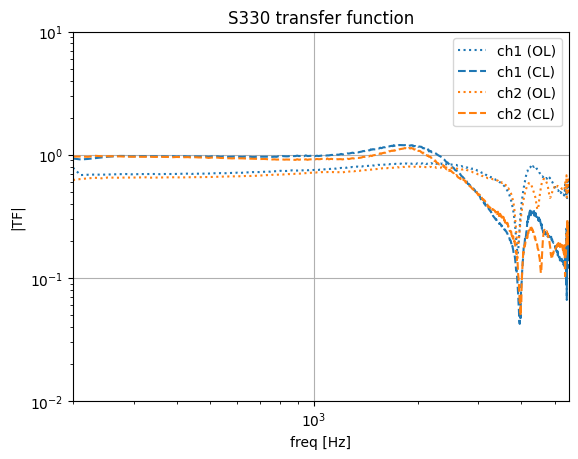

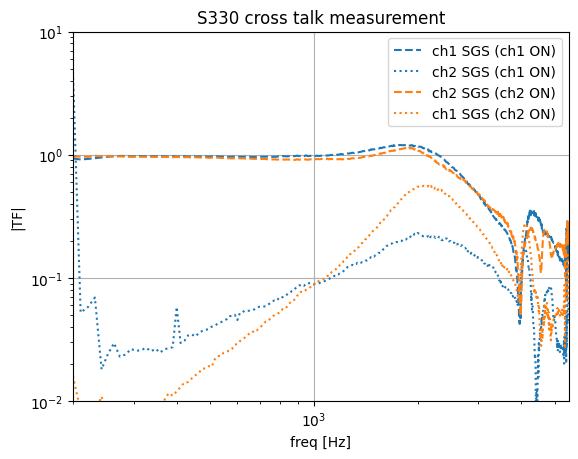

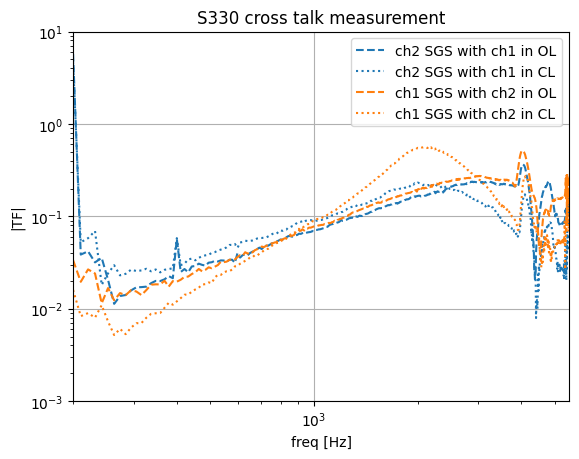

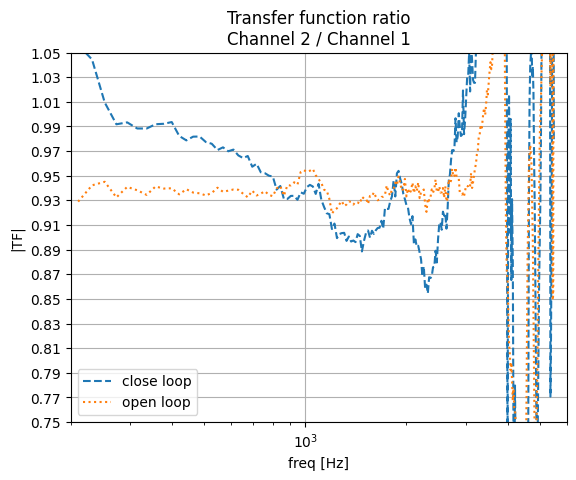

In [34]:
ch1_oltf = np.ones_like(spe1)*np.nan
ch2_oltf = np.ones_like(spe1)*np.nan
ch1_cltf = np.ones_like(spe1)*np.nan
ch2_cltf = np.ones_like(spe1)*np.nan
ch1_oltf_ct = np.ones_like(spe1)*np.nan
ch2_oltf_ct = np.ones_like(spe1)*np.nan
ch1_cltf_ct = np.ones_like(spe1)*np.nan
ch2_cltf_ct = np.ones_like(spe1)*np.nan

frange = (f>200)*(f<5500)
spe,f = get_spectra_from_tns(['20260304_111811','20260304_111857'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf[frange] = spe[1,frange]/spe[0,frange]
ch1_cltf_ct[frange] = spe[3,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260304_111236','20260304_111309'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf[frange] = spe[1,frange]/spe[0,frange]
ch1_oltf_ct[frange] = spe[3,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260304_112006','20260304_112118'],fs=freq,tstart=tstart,tend=tend)
ch2_cltf[frange] = spe[3,frange]/spe[2,frange]
ch2_cltf_ct[frange] = spe[1,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260304_112201','20260304_112228'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf[frange] = spe[3,frange]/spe[2,frange]
ch2_oltf_ct[frange] = spe[1,frange]/spe[2,frange]

dec = 100
plt.figure()
plt.plot(f[::dec],ch1_oltf[::dec],':',c='C0',label='ch1 (OL)')
plt.plot(f[::dec],ch1_cltf[::dec],'--',c='C0',label='ch1 (CL)')
plt.plot(f[::dec],ch2_oltf[::dec],':',c='C1',label='ch2 (OL)')
plt.plot(f[::dec],ch2_cltf[::dec],'--',c='C1',label='ch2 (CL)')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,5500])
plt.ylim([1e-2,10])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S330 transfer function')

plt.figure()
plt.plot(f[::dec],ch1_cltf[::dec],'--',c='C0',label='ch1 SGS (ch1 ON)')
plt.plot(f[::dec],ch1_cltf_ct[::dec],':',c='C0',label='ch2 SGS (ch1 ON)')
plt.plot(f[::dec],ch2_cltf[::dec],'--',c='C1',label='ch2 SGS (ch2 ON)')
plt.plot(f[::dec],ch2_cltf_ct[::dec],':',c='C1',label='ch1 SGS (ch2 ON)')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,5500])
plt.ylim([1e-2,10])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S330 cross talk measurement')

plt.figure()
plt.plot(f[::dec],ch1_oltf_ct[::dec],'--',c='C0',label='ch2 SGS with ch1 in OL')
plt.plot(f[::dec],ch1_cltf_ct[::dec],':',c='C0',label='ch2 SGS with ch1 in CL')
plt.plot(f[::dec],ch2_oltf_ct[::dec],'--',c='C1',label='ch1 SGS with ch2 in OL')
plt.plot(f[::dec],ch2_cltf_ct[::dec],':',c='C1',label='ch1 SGS with ch2 in CL')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,5500])
plt.ylim([1e-3,10])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S330 cross talk measurement')

dec = 200
plt.figure()
plt.plot(f[::dec],ch2_cltf[::dec]/ch1_cltf[::dec],'--',label='close loop')
plt.plot(f[::dec],ch2_oltf[::dec]/ch1_oltf[::dec],':',label='open loop')
plt.legend()
plt.grid()
plt.xscale('log')
plt.xlim([200,6000])
plt.ylim([0.75,1.02])
plt.xlabel('freq [Hz]')
plt.yticks(np.arange(16)/50+0.75)
plt.ylabel('|TF|')
plt.title('Transfer function ratio\nChannel 2 / Channel 1')

Text(0.5, 1.0, 'S331 transfer function\nChannel 2 open loop')

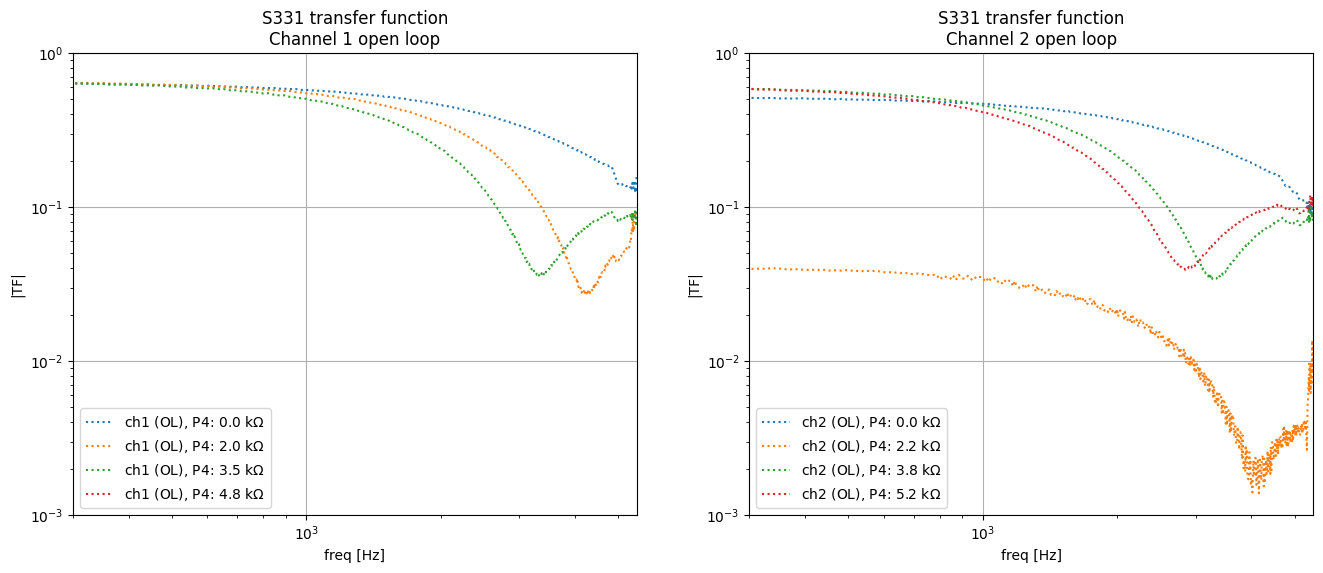

In [62]:
p4_kohm_ch1 = np.array([0.0,2.0,3.5,4.8])
p4_kohm_ch2 = np.array([0.0,2.2,3.8,5.2])
ch1_oltf_notch = np.ones([len(spe1),4])*np.nan
ch2_oltf_notch = np.ones([len(spe1),4])*np.nan

frange = (f>200)*(f<5500)
spe,f = get_spectra_from_tns(['20260304_101603','20260304_101636'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_notch[frange,0] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260304_104938','20260304_105004'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_notch[frange,1] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260304_104300','20260304_104330'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_notch[frange,2] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260304_102853','20260304_102925'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_notch[frange,3] = spe[1,frange]/spe[2,frange]

spe,f = get_spectra_from_tns(['20260304_101747','20260304_101821'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_notch[frange,0] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260304_104739','20260304_104809'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_notch[frange,1] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260304_104507','20260304_104538'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_notch[frange,2] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260304_103049','20260304_103118'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_notch[frange,3] = spe[3,frange]/spe[2,frange]

dec = 100
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
for j in range(4):
    plt.plot(f[::dec],ch1_oltf_notch[::dec,j],':',label=f'ch1 (OL), P4: {p4_kohm_ch1[j]} '+r'k$\Omega$')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([300,5500])
plt.ylim([1e-3,1])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S331 transfer function\nChannel 1 open loop')
plt.subplot(1,2,2)
for j in range(4):
    plt.plot(f[::dec],ch2_oltf_notch[::dec,j],':',label=f'ch2 (OL), P4: {p4_kohm_ch2[j]} '+r'k$\Omega$')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([300,5500])
plt.ylim([1e-3,1])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S331 transfer function\nChannel 2 open loop')

Text(0.5, 1.0, 'S330 transfer function\nChannel 2 open loop')

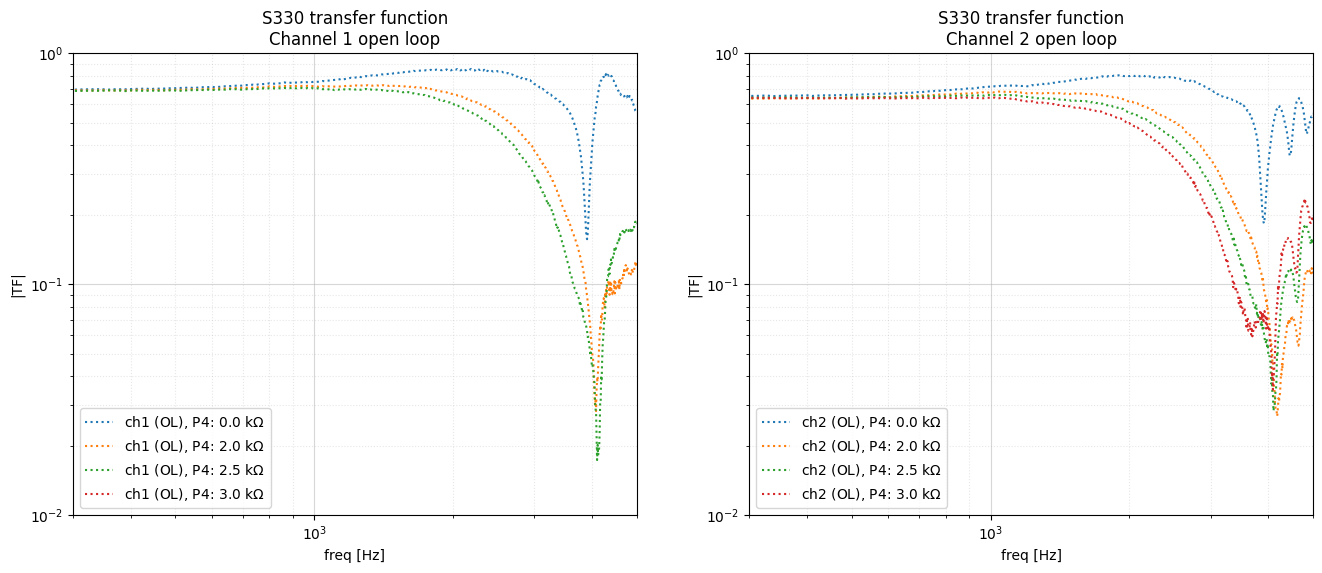

In [84]:
p4_kohm_ch1 = np.array([0.0,2.0,2.5,3.0])
p4_kohm_ch2 = np.array([0.0,2.0,2.5,3.0])
ch1_oltf_notch = np.ones([len(spe1),4])*np.nan
ch2_oltf_notch = np.ones([len(spe1),4])*np.nan

frange = (f>200)*(f<5500)
spe,f = get_spectra_from_tns(['20260304_111236','20260304_111309'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_notch[frange,0] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260304_141611','20260304_141713'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_notch[frange,1] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260304_142531','20260304_142610'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_notch[frange,2] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260304_141951','20260304_142040'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_notch[frange,3] = spe[1,frange]/spe[2,frange]

spe,f = get_spectra_from_tns(['20260304_112201','20260304_112228'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_notch[frange,0] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260304_140326','20260304_140202','20260304_140422'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_notch[frange,1] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260304_142407','20260304_142447'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_notch[frange,2] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260304_142144','20260304_142226'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_notch[frange,3] = spe[3,frange]/spe[2,frange]

dec = 100
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
for j in range(4):
    plt.plot(f[::dec],ch1_oltf_notch[::dec,j],':',label=f'ch1 (OL), P4: {p4_kohm_ch1[j]} '+r'k$\Omega$')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='major', axis='both', linestyle='-', alpha=0.5)
plt.grid(True, which='minor', axis='both', linestyle=':', alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlim([300,5000])
plt.ylim([1e-2,1])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S330 transfer function\nChannel 1 open loop')
plt.subplot(1,2,2)
for j in range(4):
    plt.plot(f[::dec],ch2_oltf_notch[::dec,j],':',label=f'ch2 (OL), P4: {p4_kohm_ch2[j]} '+r'k$\Omega$')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='major', axis='both', linestyle='-', alpha=0.5)
plt.grid(True, which='minor', axis='both', linestyle=':', alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlim([300,5000])
plt.ylim([1e-2,1])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S330 transfer function\nChannel 2 open loop')

Text(0.5, 1.0, 'S330 transfer function\nChannel 2')

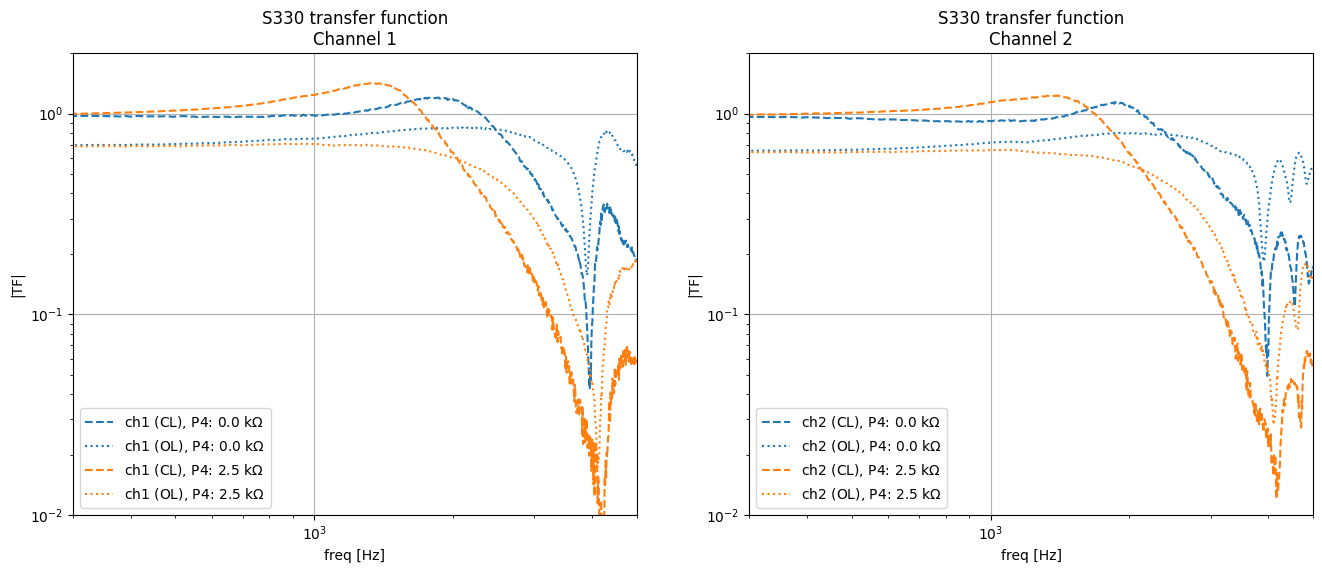

In [70]:
ch1_cltf_notch = np.ones([len(spe1),4])*np.nan
ch2_cltf_notch = np.ones([len(spe1),4])*np.nan

frange = (f>200)*(f<5500)
spe,f = get_spectra_from_tns(['20260304_111811','20260304_111857'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_notch[frange,0] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260304_142817','20260304_143119'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_notch[frange,2] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260304_112006','20260304_112118'],fs=freq,tstart=tstart,tend=tend)
ch2_cltf_notch[frange,0] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260304_143314','20260304_143350'],fs=freq,tstart=tstart,tend=tend)
ch2_cltf_notch[frange,2] = spe[3,frange]/spe[2,frange]

ids = [0,2]
dec = 100
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
for j,id in enumerate(ids):
    plt.plot(f[::dec],ch1_cltf_notch[::dec,id],'--',c=f'C{j}',label=f'ch1 (CL), P4: {p4_kohm_ch1[id]} '+r'k$\Omega$')
    plt.plot(f[::dec],ch1_oltf_notch[::dec,id],':',c=f'C{j}',label=f'ch1 (OL), P4: {p4_kohm_ch1[id]} '+r'k$\Omega$')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([300,5000])
plt.ylim([1e-2,2])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S330 transfer function\nChannel 1')
plt.subplot(1,2,2)
for j,id in enumerate(ids):
    plt.plot(f[::dec],ch2_cltf_notch[::dec,id],'--',c=f'C{j}',label=f'ch2 (CL), P4: {p4_kohm_ch2[id]} '+r'k$\Omega$')
    plt.plot(f[::dec],ch2_oltf_notch[::dec,id],':',c=f'C{j}',label=f'ch2 (OL), P4: {p4_kohm_ch2[id]} '+r'k$\Omega$')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([300,5000])
plt.ylim([1e-2,2])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('S330 transfer function\nChannel 2')


Text(0.5, 1.0, 'Channel 2\n$\\dfrac{TF(P4=0.0\\,k\\Omega)}{TF(P4=2.5\\,k\\Omega)}$')

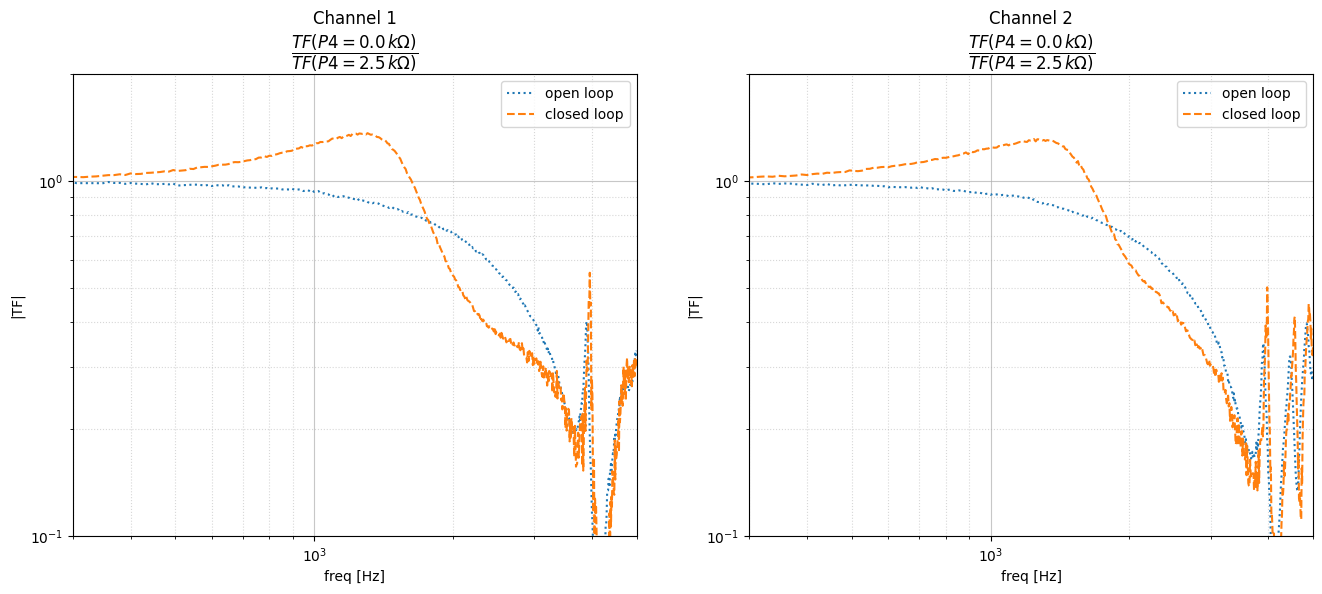

In [86]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(f[::dec],ch1_oltf_notch[::dec,2]/ch1_oltf_notch[::dec,0],':',label=f'open loop')
plt.plot(f[::dec],ch1_cltf_notch[::dec,2]/ch1_cltf_notch[::dec,0],'--',label=f'closed loop')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='major', axis='both', linestyle='-', alpha=0.7)
plt.grid(True, which='minor', axis='both', linestyle=':', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlim([300,5000])
plt.ylim([1e-1,2])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('Channel 1\n'+r'$\dfrac{TF(P4=0.0\,k\Omega)}{TF(P4=2.5\,k\Omega)}$')
plt.subplot(1,2,2)
plt.plot(f[::dec],ch2_oltf_notch[::dec,2]/ch2_oltf_notch[::dec,0],':',label=f'open loop')
plt.plot(f[::dec],ch2_cltf_notch[::dec,2]/ch2_cltf_notch[::dec,0],'--',label=f'closed loop')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='major', axis='both', linestyle='-', alpha=0.7)
plt.grid(True, which='minor', axis='both', linestyle=':', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlim([300,5000])
plt.ylim([1e-1,2])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('Channel 2\n'+r'$\dfrac{TF(P4=0.0\,k\Omega)}{TF(P4=2.5\,k\Omega)}$')

In [6]:
frange = (f>100)*(f<4800)
frangeB = (f>100)*(f<1000) + (f>1500)*(f<4800)

ch1_oltf = np.ones_like(f)*np.nan
ch2_oltf = np.ones_like(f)*np.nan
ch1_cltf_B = np.ones_like(f)*np.nan
ch1_cltf_D = np.ones_like(f)*np.nan
ch1_cltf_E = np.ones_like(f)*np.nan
ch1_cltf_F = np.ones_like(f)*np.nan
ch1_cltf_G = np.ones_like(f)*np.nan
ch1_cltf_H = np.ones_like(f)*np.nan
ch1_cltf_I = np.ones_like(f)*np.nan
ch1_cltf_J = np.ones_like(f)*np.nan
ch1_cltf_K = np.ones_like(f)*np.nan
ch1_cltf_L = np.ones_like(f)*np.nan
ch1_cltf_M = np.ones_like(f)*np.nan
ch1_cltf_N = np.ones_like(f)*np.nan

spe,f = get_spectra_from_tns(['20260227_084751','20260227_084814'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_085126','20260227_085154'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf[frange] = spe[3,frange]/spe[2,frange]

spe,f = get_spectra_from_tns(['20260227_092000','20260227_092021','20260227_092139','20260227_092200','20260227_092255','20260227_092318'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_B[frangeB] = spe[1,frangeB]/spe[0,frangeB]

spe,f = get_spectra_from_tns(['20260227_093334','20260227_093419','20260227_093510','20260227_093538','20260227_093703','20260227_093745'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_D[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_094834','20260227_094853'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_E[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_095123','20260227_095142'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_F[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_095446','20260227_095505'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_G[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_095929','20260227_100012'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_H[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_100400','20260227_100437'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_I[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_100634','20260227_100716'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_J[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_101112','20260227_101132'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_K[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_101628','20260227_101700'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_L[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_101855','20260227_102052'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_M[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_102224','20260227_102142'],fs=freq,tstart=tstart,tend=tend)
ch1_cltf_N[frange] = spe[1,frange]/spe[0,frange]


Text(0.5, 1.0, 'Ch1 transfer function\nDifferent gains')

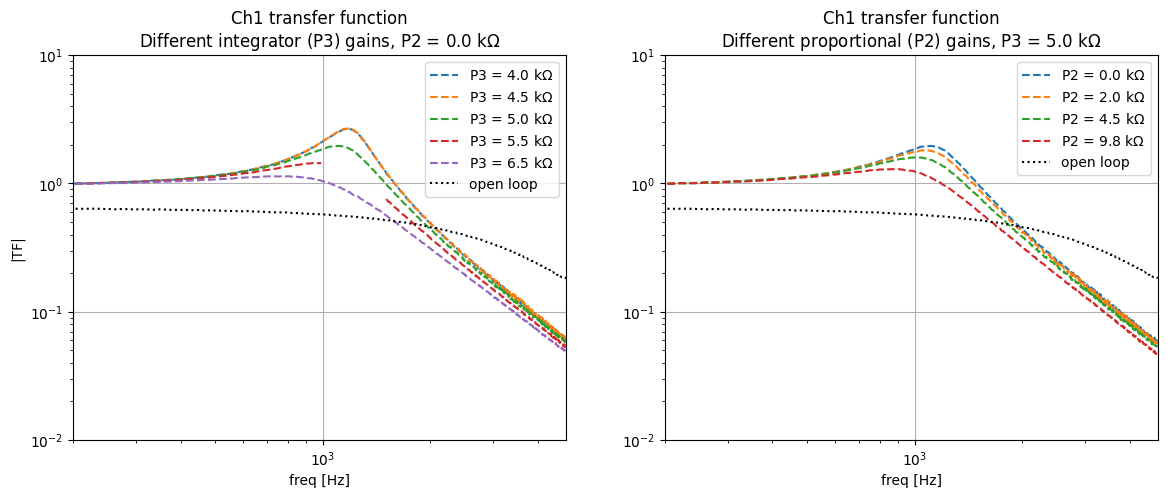

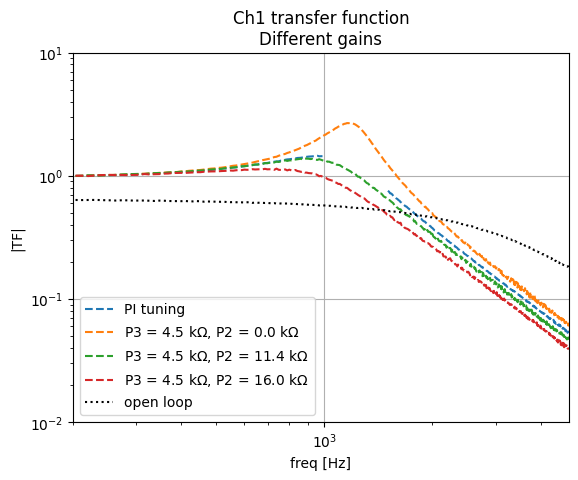

In [7]:
dec = 100
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(f[::dec],ch1_cltf[::dec],'--',label=r'P3 = 4.0 k$\Omega$')
plt.plot(f[::dec],ch1_cltf_L[::dec],'--',label=r'P3 = 4.5 k$\Omega$')
plt.plot(f[::dec],ch1_cltf_K[::dec],'--',label=r'P3 = 5.0 k$\Omega$')
plt.plot(f[::dec],ch1_cltf_B[::dec],'--',label=r'P3 = 5.5 k$\Omega$')
plt.plot(f[::dec],ch1_cltf_D[::dec],'--',label=r'P3 = 6.5 k$\Omega$')
plt.plot(f[::dec],ch1_oltf[::dec],':',c='k',label=r'open loop')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,4800])
plt.ylim([1e-2,10])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('Ch1 transfer function\nDifferent integrator (P3) gains, P2 = 0.0 '+r'k$\Omega$')
plt.subplot(1,2,2)
plt.plot(f[::dec],ch1_cltf_K[::dec],'--',label=r'P2 = 0.0 k$\Omega$')
plt.plot(f[::dec],ch1_cltf_H[::dec],'--',label=r'P2 = 2.0 k$\Omega$')
plt.plot(f[::dec],ch1_cltf_I[::dec],'--',label=r'P2 = 4.5 k$\Omega$')
plt.plot(f[::dec],ch1_cltf_J[::dec],'--',label=r'P2 = 9.8 k$\Omega$')
plt.plot(f[::dec],ch1_oltf[::dec],':',c='k',label=r'open loop')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,4800])
plt.ylim([1e-2,10])
plt.xlabel('freq [Hz]')
plt.title('Ch1 transfer function\nDifferent proportional (P2) gains, P3 = 5.0 '+r'k$\Omega$')



plt.figure()
plt.plot(f[::dec],ch1_cltf_B[::dec],'--',label=r'PI tuning')
plt.plot(f[::dec],ch1_cltf_L[::dec],'--',label=r'P3 = 4.5 k$\Omega$, P2 = 0.0 k$\Omega$')
plt.plot(f[::dec],ch1_cltf_M[::dec],'--',label=r'P3 = 4.5 k$\Omega$, P2 = 11.4 k$\Omega$')
plt.plot(f[::dec],ch1_cltf_N[::dec],'--',label=r'P3 = 4.5 k$\Omega$, P2 = 16.0 k$\Omega$')
plt.plot(f[::dec],ch1_oltf[::dec],':',c='k',label=r'open loop')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,4800])
plt.ylim([1e-2,10])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('Ch1 transfer function\nDifferent gains')



In [8]:
frange = (f>100)*(f<4800)

ch1_oltf_i0_f0 = np.ones_like(f)*np.nan
ch1_oltf_i0_f2 = np.ones_like(f)*np.nan
ch1_oltf_i0_f5 = np.ones_like(f)*np.nan
ch1_oltf_i0_f7 = np.ones_like(f)*np.nan
ch1_oltf_i2_f0 = np.ones_like(f)*np.nan
ch1_oltf_i5_f0 = np.ones_like(f)*np.nan
ch1_oltf_i7_f0 = np.ones_like(f)*np.nan
ch1_oltf_i2_f2 = np.ones_like(f)*np.nan
ch1_oltf_i5_f5 = np.ones_like(f)*np.nan
ch1_oltf_i7_f7 = np.ones_like(f)*np.nan
ch2_oltf_i0_f0 = np.ones_like(f)*np.nan
ch2_oltf_i2_f0 = np.ones_like(f)*np.nan
ch2_oltf_i5_f0 = np.ones_like(f)*np.nan
ch2_oltf_i7_f0 = np.ones_like(f)*np.nan

spe,f = get_spectra_from_tns(['20260227_130648','20260227_130707'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i0_f0[frange] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_123517','20260227_123536'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i0_f2[frange] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_123735','20260227_123754'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i0_f5[frange] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_123942','20260227_124003'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i0_f7[frange] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_115805','20260227_115826'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i2_f0[frange] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_121938','20260227_121956'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i5_f0[frange] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_122152','20260227_122215'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i7_f0[frange] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_124600','20260227_124618'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i2_f2[frange] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_124332','20260227_124357'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i5_f5[frange] = spe[1,frange]/spe[0,frange]
spe,f = get_spectra_from_tns(['20260227_124142','20260227_124202'],fs=freq,tstart=tstart,tend=tend)
ch1_oltf_i7_f7[frange] = spe[1,frange]/spe[0,frange]

spe,f = get_spectra_from_tns(['20260227_130756','20260227_130819'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_i0_f0[frange] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260227_123039','20260227_123059'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_i2_f0[frange] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260227_122859','20260227_122923'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_i5_f0[frange] = spe[3,frange]/spe[2,frange]
spe,f = get_spectra_from_tns(['20260227_122708','20260227_122727'],fs=freq,tstart=tstart,tend=tend)
ch2_oltf_i7_f0[frange] = spe[3,frange]/spe[2,frange]

Text(0.5, 1.0, 'Ch1 open-loop response\nIncreasing feedback and input cable length')

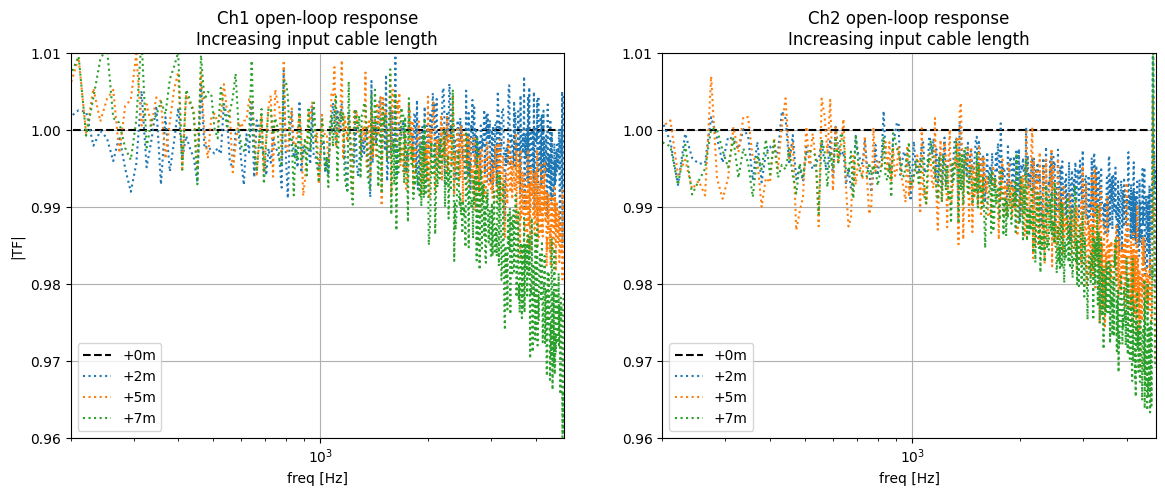

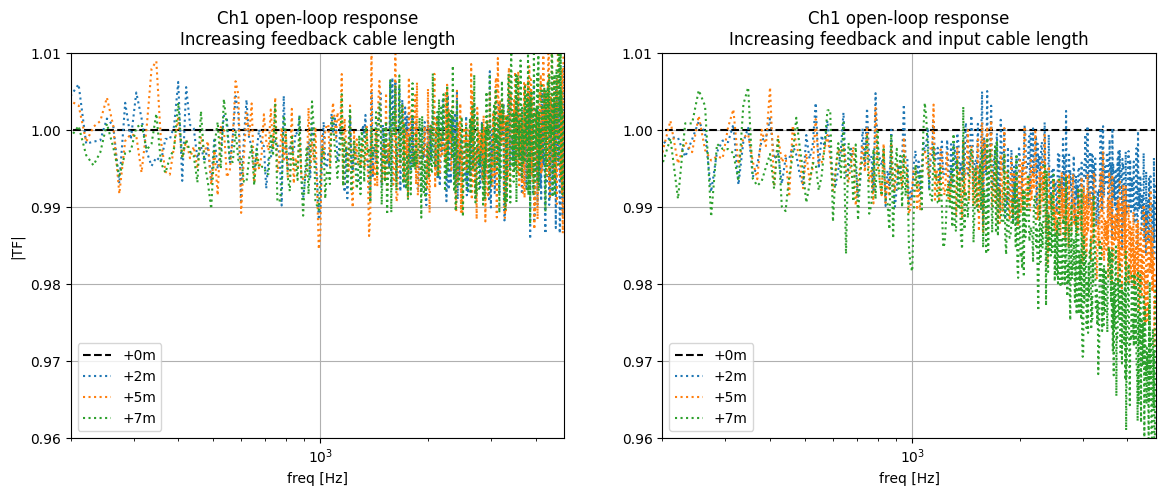

In [9]:
dec = 100
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(f[::dec],ch1_oltf_i0_f0[::dec]/ch1_oltf_i0_f0[::dec],'--',c='k',label='+0m')
plt.plot(f[::dec],ch1_oltf_i2_f0[::dec]/ch1_oltf_i0_f0[::dec],':',label='+2m')
plt.plot(f[::dec],ch1_oltf_i5_f0[::dec]/ch1_oltf_i0_f0[::dec],':',label='+5m')
plt.plot(f[::dec],ch1_oltf_i7_f0[::dec]/ch1_oltf_i0_f0[::dec],':',label='+7m')
plt.legend()
plt.grid()
plt.xscale('log')
# plt.yscale('log')
plt.ylim([0.96,1.01])
plt.xlim([200,4800])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('Ch1 open-loop response\nIncreasing input cable length')
plt.subplot(1,2,2)
plt.plot(f[::dec],ch2_oltf_i0_f0[::dec]/ch2_oltf_i0_f0[::dec],'--',c='k',label='+0m')
plt.plot(f[::dec],ch2_oltf_i2_f0[::dec]/ch2_oltf_i0_f0[::dec],':',label='+2m')
plt.plot(f[::dec],ch2_oltf_i5_f0[::dec]/ch2_oltf_i0_f0[::dec],':',label='+5m')
plt.plot(f[::dec],ch2_oltf_i7_f0[::dec]/ch2_oltf_i0_f0[::dec],':',label='+7m')
plt.legend()
plt.grid()
plt.xscale('log')
plt.ylim([0.96,1.01])
plt.xlim([200,4800])
plt.xlabel('freq [Hz]')
plt.title('Ch2 open-loop response\nIncreasing input cable length')

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(f[::dec],ch1_oltf_i0_f0[::dec]/ch1_oltf_i0_f0[::dec],'--',c='k',label='+0m')
plt.plot(f[::dec],ch1_oltf_i0_f2[::dec]/ch1_oltf_i0_f0[::dec],':',label='+2m')
plt.plot(f[::dec],ch1_oltf_i0_f5[::dec]/ch1_oltf_i0_f0[::dec],':',label='+5m')
plt.plot(f[::dec],ch1_oltf_i0_f7[::dec]/ch1_oltf_i0_f0[::dec],':',label='+7m')
plt.legend()
plt.grid()
plt.xscale('log')
# plt.yscale('log')
plt.ylim([0.96,1.01])
plt.xlim([200,4800])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('Ch1 open-loop response\nIncreasing feedback cable length')
plt.subplot(1,2,2)
plt.plot(f[::dec],ch1_oltf_i0_f0[::dec]/ch1_oltf_i0_f0[::dec],'--',c='k',label='+0m')
plt.plot(f[::dec],ch1_oltf_i2_f2[::dec]/ch1_oltf_i0_f0[::dec],':',label='+2m')
plt.plot(f[::dec],ch1_oltf_i5_f5[::dec]/ch1_oltf_i0_f0[::dec],':',label='+5m')
plt.plot(f[::dec],ch1_oltf_i7_f7[::dec]/ch1_oltf_i0_f0[::dec],':',label='+7m')
plt.legend()
plt.grid()
plt.xscale('log')
# plt.yscale('log')
plt.ylim([0.96,1.01])
plt.xlim([200,4800])
plt.xlabel('freq [Hz]')
plt.title('Ch1 open-loop response\nIncreasing feedback and input cable length')